# Fase 9 · ¿Causó el COVID el aumento de la hospitalización psiquiátrica?
### Análisis de quiebre de tendencia (segmented regression + contrafactual)

**Hipótesis a probar.** El aumento de la hospitalización psiquiátrica, ¿fue *causado* por
el COVID, o ya era una tendencia previa que la pandemia solo continuó / aceleró? No basta
con ver si subió: hay que demostrar si hubo un **quiebre de tendencia** coincidente con la
pandemia, más allá de lo que la tendencia pre-COVID ya predecía.

**Salvedad metodológica.** Los datos REM20 miden **volumen y flujo** (camas, egresos, días
de estada), **no diagnóstico clínico por patología**. Este estudio analiza la hospitalización
psiquiátrica **agregada**. La única granularidad disponible es estructural (Adulto / Infanto,
Corta / Mediana / Larga estadía, Forense, Cuidados Intensivos), no por enfermedad. No se
afirma causalidad clínica que el dato no pueda sostener.

**Fuente:** `rem20.indicadores` (MINSAL REM20, 2014-2026).


In [1]:
import os, warnings
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
warnings.filterwarnings('ignore')
from dotenv import load_dotenv
from sqlalchemy import create_engine
from urllib.parse import quote_plus
import statsmodels.api as sm
import statsmodels.formula.api as smf

# localizar la raiz del proyecto (donde vive .env) subiendo desde el cwd
ROOT = Path.cwd()
while not (ROOT / '.env').exists() and ROOT != ROOT.parent:
    ROOT = ROOT.parent
load_dotenv(dotenv_path=ROOT / '.env', override=True)
GRAF = ROOT / 'data' / 'processed' / 'graficos_salud_mental'
GRAF.mkdir(parents=True, exist_ok=True)

url = (f"postgresql+psycopg2://{os.getenv('DB_USER')}:{quote_plus(os.getenv('DB_PASSWORD'))}"
       f"@{os.getenv('DB_HOST')}:{os.getenv('DB_PORT')}/{os.getenv('DB_NAME')}")
eng = create_engine(url)

# Segmento validado (Paso 0). Definido por codigo, robusto al mojibake del texto.
CLINICO = (418, 419, 420, 421, 422, 428, 429)   # psiquiatria clinica
FORENSE = (423, 424, 425, 426)                   # flujo judicial, se analiza aparte
TOTAL   = CLINICO + FORENSE
COVID = pd.Timestamp('2020-03-01')   # punto de interrupcion (inicio pandemia en Chile)
POST  = pd.Timestamp('2022-01-01')   # fin de la fase aguda

plt.rcParams.update({'figure.figsize': (12, 6), 'axes.grid': True,
                     'grid.alpha': 0.25, 'font.size': 11})
PIE = 'Fuente: MINSAL REM20 2014-2026'
def pie(ax):
    ax.annotate(PIE, xy=(0.99, -0.13), xycoords='axes fraction', ha='right',
                va='top', fontsize=8, color='gray')
print('Proyecto:', ROOT)


Proyecto: C:\Users\matia\Memoria\proyectos\Analisis_Hospitalario


## Paso 0 · Segmento de salud mental

El segmento se define por **`cod_area_funcional`** (no por el texto, que tiene variantes y
mojibake) y por **área funcional** (no por establecimiento): así se captura la hospitalización
psiquiátrica tanto de hospitales especializados como de unidades psiquiátricas dentro de
hospitales generales. Se excluye el cód 427 (*Área Sociosanitaria Adulto*, cuidado social, no
psiquiátrico). La **psiquiatría forense** (423-426) se analiza por separado porque responde a
flujos del sistema judicial, no a demanda epidemiológica.


In [2]:
def serie(codes=None, control=False):
    where = ("cod_area_funcional NOT BETWEEN 418 AND 429" if control
             else f"cod_area_funcional IN ({','.join(map(str, codes))})")
    q = f'''SELECT make_date(periodo, mes, 1) AS fecha,
                   SUM(numero_egresos)        AS egresos,
                   SUM(dias_camas_ocupadas)   AS ocup,
                   SUM(dias_camas_disponibles) AS disp
            FROM rem20.indicadores WHERE {where}
            GROUP BY make_date(periodo, mes, 1) ORDER BY fecha'''
    df = pd.read_sql(q, eng, parse_dates=['fecha']).set_index('fecha').asfreq('MS')
    df['ocup_pct'] = 100.0 * df['ocup'] / df['disp']
    df['t'] = np.arange(len(df))
    df['mes'] = df.index.month
    df['D'] = (df.index >= COVID).astype(int)
    t_c = df.loc[df.index >= COVID, 't'].min()
    df['t_post'] = np.where(df['D'] == 1, df['t'] - t_c, 0)
    return df

clin = serie(CLINICO); total = serie(TOTAL); forense = serie(FORENSE); ctrl = serie(control=True)
resumen = pd.DataFrame({
    'meses':        [len(clin), len(total), len(forense), len(ctrl)],
    'egresos/mes':  [d['egresos'].mean() for d in (clin, total, forense, ctrl)],
    'ocup_%_media': [d['ocup_pct'].mean() for d in (clin, total, forense, ctrl)],
}, index=['Clínico', 'Total', 'Forense', 'Control (resto)']).round(1)
resumen


,meses,egresos/mes,ocup_%_media
Clínico,149,1143.0,87.2
Total,149,1171.6,87.5
Forense,149,28.5,89.4
Control (resto),149,82155.4,77.8


## Sección 1 · Series de demanda (2014-2026)

Serie mensual del segmento para los dos indicadores de demanda: **egresos** (altas = pacientes
atendidos) y **ocupación de camas** (presión sobre el sistema). Se marcan tres zonas:
pre-COVID (2014-feb2020), COVID (mar2020-2021) y post-COVID (2022-2026).


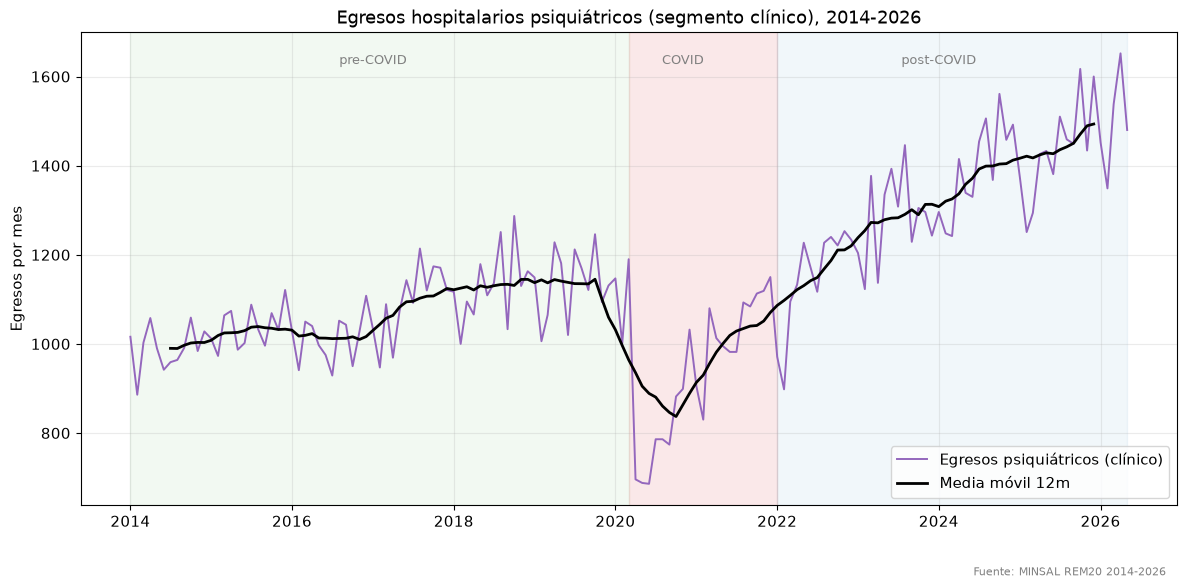

In [3]:
def zonas(ax):
    ax.axvspan(clin.index.min(), COVID, color='tab:green', alpha=0.06)
    ax.axvspan(COVID, POST, color='tab:red', alpha=0.10)
    ax.axvspan(POST, clin.index.max(), color='tab:blue', alpha=0.06)
    for x, txt in [(pd.Timestamp('2017-01-01'), 'pre-COVID'),
                   (pd.Timestamp('2020-11-01'), 'COVID'),
                   (pd.Timestamp('2024-01-01'), 'post-COVID')]:
        ax.text(x, ax.get_ylim()[1]*0.97, txt, ha='center', va='top', fontsize=9, color='gray')

fig, ax = plt.subplots()
ax.plot(clin.index, clin['egresos'], color='tab:purple', lw=1.4, label='Egresos psiquiátricos (clínico)')
ax.plot(clin.index, clin['egresos'].rolling(12, center=True).mean(), color='black', lw=2,
        label='Media móvil 12m')
zonas(ax)
ax.set_title('Egresos hospitalarios psiquiátricos (segmento clínico), 2014-2026')
ax.set_ylabel('Egresos por mes'); ax.legend(loc='lower right'); pie(ax)
fig.tight_layout(); fig.savefig(GRAF / '01_series_egresos_zonas.png', dpi=150, bbox_inches='tight')
plt.show()


## Sección 2 · Técnica 1 — Quiebre de tendencia (segmented regression / ITS)

Modelo de **series temporales interrumpidas** con control de **estacionalidad mensual** y
**errores HAC (Newey-West)** para la autocorrelación:

$$y_t = \beta_0 + \beta_1 t + \beta_2 D_t + \beta_3 (t-t_{cov})D_t + \sum_m \gamma_m \text{mes}_m + \varepsilon_t$$

- $\beta_1$ = pendiente **pre-COVID** (¿ya venía subiendo?)
- $\beta_2$ = cambio de **nivel** en marzo 2020
- $\beta_3$ = cambio de **pendiente** posterior

Se reporta además un **test de quiebre estructural** (F conjunto sobre $\beta_2,\beta_3$;
equivalente a un Chow test en fecha conocida, con covarianza robusta).


In [4]:
def its(df, y):
    m = smf.ols(f"{y} ~ t + D + t_post + C(mes)", data=df).fit(
        cov_type='HAC', cov_kwds={'maxlags': 12})
    pre = df[df.index < COVID]
    mp = smf.ols(f"{y} ~ t + C(mes)", data=pre).fit()
    ftest = m.f_test("D = 0, t_post = 0")     # quiebre estructural conjunto
    return m, mp, ftest

filas = []
for seg, df in [('Clínico', clin), ('Total', total)]:
    for y, u in [('egresos', 'egresos/mes'), ('ocup_pct', 'puntos %')]:
        m, mp, ft = its(df, y)
        filas.append({
            'segmento': seg, 'indicador': y,
            'pend_pre_anual': round(mp.params['t']*12, 2),
            'p_pre': round(mp.pvalues['t'], 4),
            'cambio_nivel': round(m.params['D'], 2), 'p_nivel': round(m.pvalues['D'], 4),
            'cambio_pend_anual': round(m.params['t_post']*12, 2), 'p_pend': round(m.pvalues['t_post'], 4),
            'F_quiebre': round(float(np.ravel(ft.fvalue)[0]), 1), 'p_quiebre': round(float(ft.pvalue), 6),
        })
its_tab = pd.DataFrame(filas)
its_tab


,segmento,indicador,pend_pre_anual,p_pre,cambio_nivel,p_nivel,cambio_pend_anual,p_pend,F_quiebre,p_quiebre
0,Clínico,egresos,29.97,0.0000,-309.97,0.0,88.66,0.0,44.9,0.0
1,Clínico,ocup_pct,0.05,0.6160,-11.66,0.0,2.28,0.0,74.3,0.0
2,Total,egresos,29.72,0.0000,-322.44,0.0,89.43,0.0,48.9,0.0
3,Total,ocup_pct,0.01,0.9143,-10.76,0.0,2.34,0.0,81.8,0.0


**Lectura.** En **egresos** la pendiente pre-COVID es fuerte y muy significativa
(≈ +30/mes por año): la hospitalización psiquiátrica **ya crecía antes de la pandemia**. El
cambio de nivel en marzo 2020 es **negativo** (el COVID *hundió* los egresos en la fase aguda),
seguido de una pendiente de recuperación más empinada. En **ocupación** la pendiente pre-COVID
es plana (no significativa): más egresos sin más camas ocupadas ⇒ mayor rotación / estadías más
cortas.


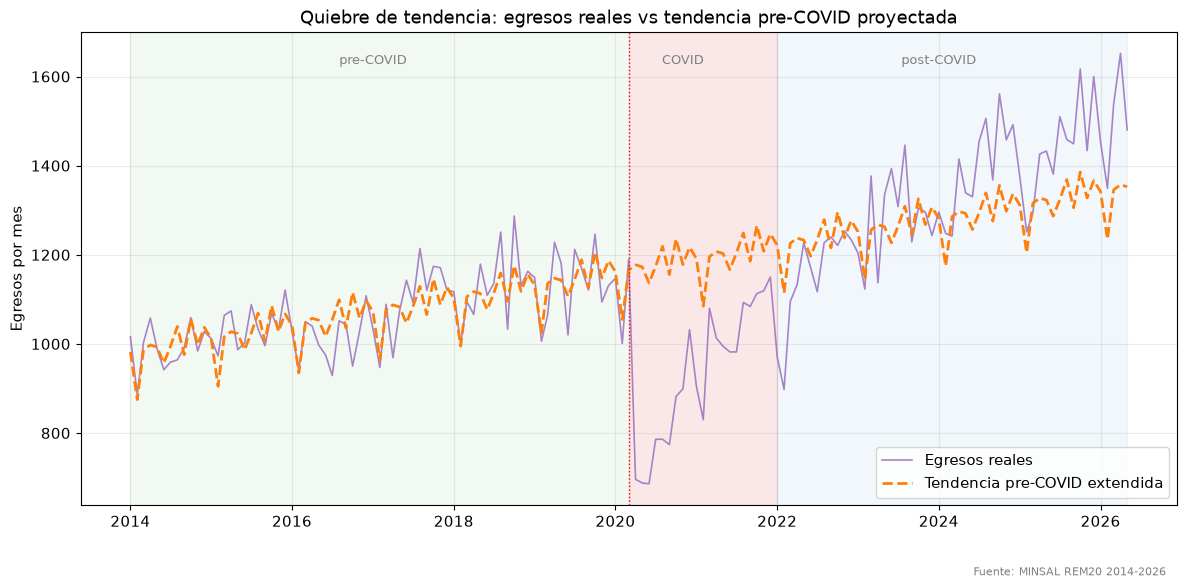

In [5]:
# Visual del quiebre: tendencia pre-COVID extendida (contrafactual de tendencia) vs real
fig, ax = plt.subplots()
y = 'egresos'
mp = smf.ols(f"{y} ~ t + C(mes)", data=clin[clin.index < COVID]).fit()
tend = mp.predict(clin)                       # extiende tendencia+estacionalidad pre a todo
ax.plot(clin.index, clin[y], color='tab:purple', lw=1.2, alpha=0.8, label='Egresos reales')
ax.plot(clin.index, tend, color='tab:orange', lw=2, ls='--',
        label='Tendencia pre-COVID extendida')
ax.axvline(COVID, color='red', lw=1, ls=':'); zonas(ax)
ax.set_title('Quiebre de tendencia: egresos reales vs tendencia pre-COVID proyectada')
ax.set_ylabel('Egresos por mes'); ax.legend(loc='lower right'); pie(ax)
fig.tight_layout(); fig.savefig(GRAF / '02_quiebre_tendencia.png', dpi=150, bbox_inches='tight')
plt.show()


## Sección 3 · Técnica 2 — Contrafactual (proyección de la tendencia previa)

Se ajusta un modelo usando **solo datos pre-COVID** (tendencia + estacionalidad) y se proyecta
a 2020-2026 *como si la pandemia no hubiera ocurrido*. La **brecha** entre lo observado y el
contrafactual es el efecto candidato atribuible al COVID, con banda de predicción al 95%.


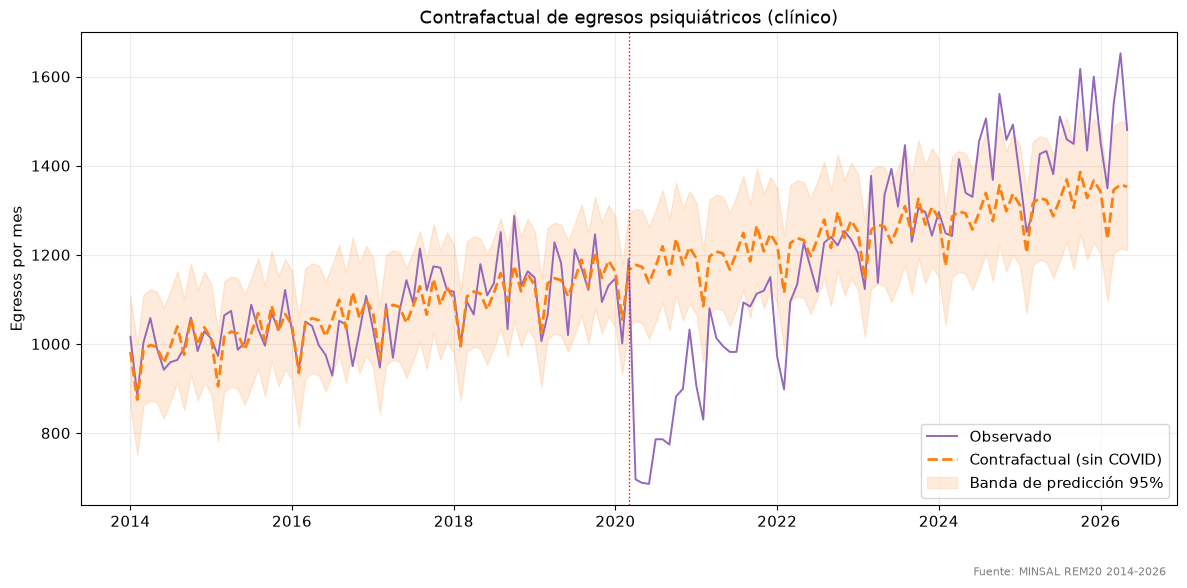

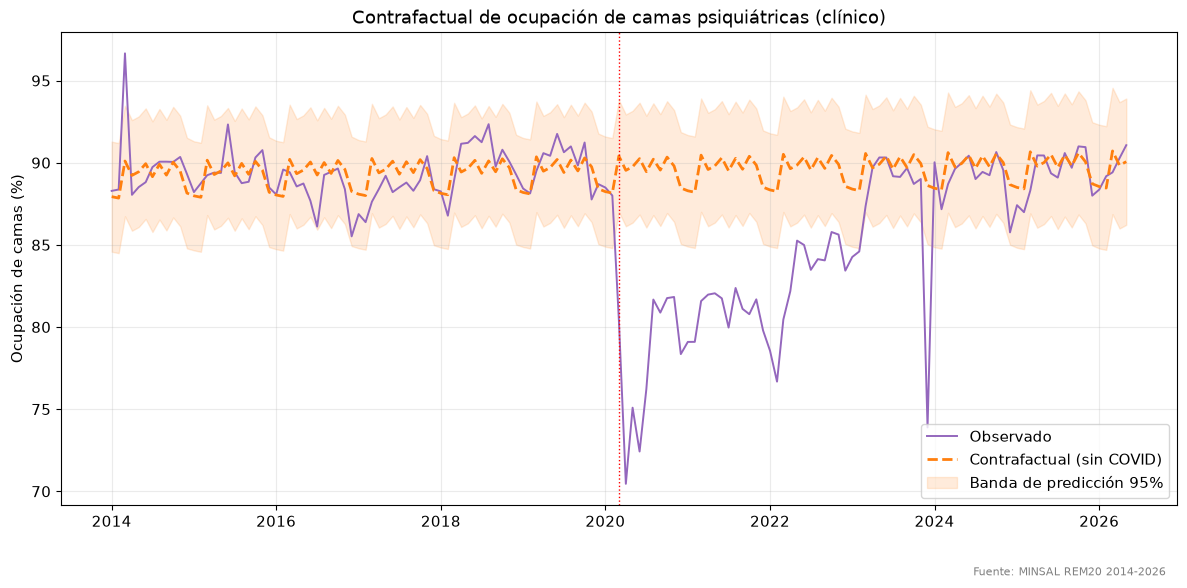

Egresos  : {'brecha_covid': np.float64(-248.9), 'brecha_post': np.float64(51.5), 'post_vs_esperado_%': np.float64(4.0)}
Ocupación: {'brecha_covid': np.float64(-10.1), 'brecha_post': np.float64(-2.3), 'post_vs_esperado_%': np.float64(-2.6)}


In [6]:
def contrafactual(df, y):
    pre = df[df.index < COVID]
    m = smf.ols(f"{y} ~ t + C(mes)", data=pre).fit()
    pr = m.get_prediction(df).summary_frame(alpha=0.05)
    out = df[[y]].copy()
    out['cf'] = pr['mean'].values
    out['lo'] = pr['obs_ci_lower'].values
    out['hi'] = pr['obs_ci_upper'].values
    out['gap'] = out[y] - out['cf']
    return out

def plot_cf(df, y, titulo, ylabel, fname):
    cf = contrafactual(df, y)
    fig, ax = plt.subplots()
    ax.plot(cf.index, cf[y], color='tab:purple', lw=1.4, label='Observado')
    ax.plot(cf.index, cf['cf'], color='tab:orange', lw=2, ls='--', label='Contrafactual (sin COVID)')
    ax.fill_between(cf.index, cf['lo'], cf['hi'], color='tab:orange', alpha=0.15,
                    label='Banda de predicción 95%')
    ax.axvline(COVID, color='red', lw=1, ls=':')
    ax.set_title(titulo); ax.set_ylabel(ylabel); ax.legend(loc='lower right'); pie(ax)
    fig.tight_layout(); fig.savefig(GRAF / fname, dpi=150, bbox_inches='tight'); plt.show()
    covid_zone = cf[(cf.index >= COVID) & (cf.index < POST)]
    post_zone = cf[cf.index >= POST]
    return {'brecha_covid': round(covid_zone['gap'].mean(), 1),
            'brecha_post': round(post_zone['gap'].mean(), 1),
            'post_vs_esperado_%': round(100*post_zone['gap'].mean()/post_zone['cf'].mean(), 1)}

g_eg = plot_cf(clin, 'egresos', 'Contrafactual de egresos psiquiátricos (clínico)',
               'Egresos por mes', '03_contrafactual_egresos.png')
g_oc = plot_cf(clin, 'ocup_pct', 'Contrafactual de ocupación de camas psiquiátricas (clínico)',
               'Ocupación de camas (%)', '04_contrafactual_ocupacion.png')
print('Egresos  :', g_eg)
print('Ocupación:', g_oc)


**Lectura.** Durante la fase aguda (2020-2021) los egresos quedaron muy **por debajo** de
lo esperado (caída atribuible a la contracción de la actividad hospitalaria). En post-COVID
(2022-2026) se recuperaron **por encima** de la tendencia previa (≈ +4%). La ocupación, en
cambio, **no** ha vuelto a superar su nivel pre-pandemia.


## Sección 4 · Grupo de control y diferencias en diferencias

Se repite el contrafactual para el **resto del sistema** (no psiquiátrico). Si todo el sistema
se moviera igual, el efecto no sería específico de salud mental. La comparación tipo
*diferencias en diferencias* mide si la desviación psiquiátrica fue mayor que la del control.


Psiquiatría clínica  POST vs esperado: +4.0%
Resto del sistema    POST vs esperado: -5.2%
Diff-in-diff (psiq - control)        : +9.2 puntos %


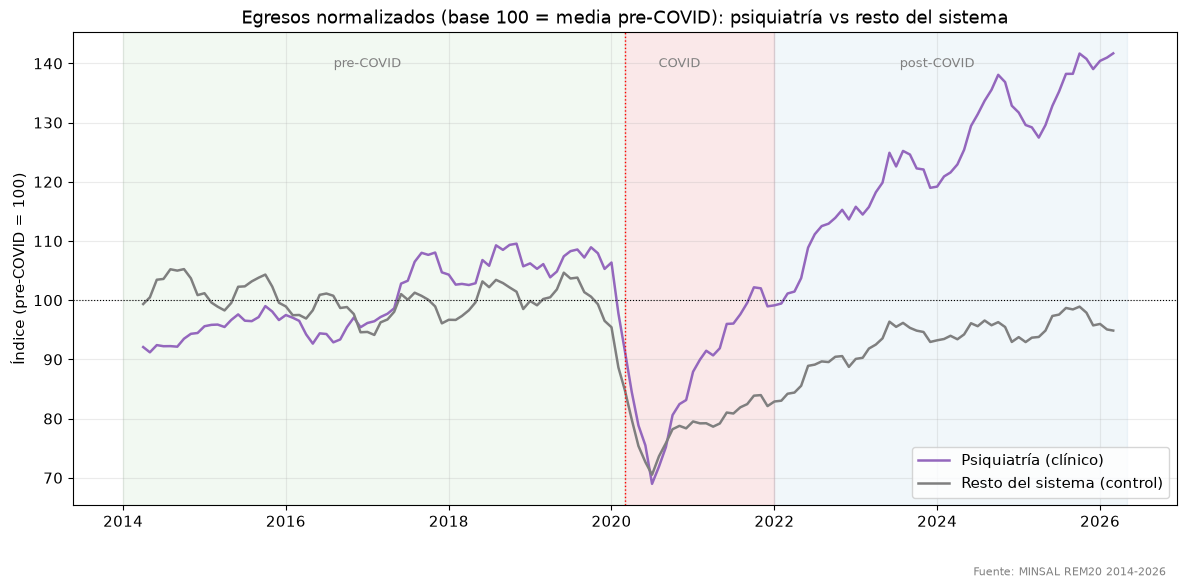

In [7]:
rel_clin = contrafactual(clin, 'egresos')
rel_clin = rel_clin[rel_clin.index >= POST]
rel_clin_pct = 100*rel_clin['gap'].mean()/rel_clin['cf'].mean()
rel_ctrl = contrafactual(ctrl, 'egresos')
rel_ctrl = rel_ctrl[rel_ctrl.index >= POST]
rel_ctrl_pct = 100*rel_ctrl['gap'].mean()/rel_ctrl['cf'].mean()
did = rel_clin_pct - rel_ctrl_pct
print(f"Psiquiatría clínica  POST vs esperado: {rel_clin_pct:+.1f}%")
print(f"Resto del sistema    POST vs esperado: {rel_ctrl_pct:+.1f}%")
print(f"Diff-in-diff (psiq - control)        : {did:+.1f} puntos %")

# Series normalizadas (base 100 = media pre-COVID) para comparar trayectorias
fig, ax = plt.subplots()
for df, lab, col in [(clin, 'Psiquiatría (clínico)', 'tab:purple'),
                     (ctrl, 'Resto del sistema (control)', 'tab:gray')]:
    base = df.loc[df.index < COVID, 'egresos'].mean()
    norm = (df['egresos'] / base * 100).rolling(6, center=True).mean()
    ax.plot(df.index, norm, lw=1.8, color=col, label=lab)
ax.axhline(100, color='black', lw=0.8, ls=':'); ax.axvline(COVID, color='red', lw=1, ls=':')
zonas(ax)
ax.set_title('Egresos normalizados (base 100 = media pre-COVID): psiquiatría vs resto del sistema')
ax.set_ylabel('Índice (pre-COVID = 100)'); ax.legend(loc='lower right'); pie(ax)
fig.tight_layout(); fig.savefig(GRAF / '05_control_did.png', dpi=150, bbox_inches='tight')
plt.show()


**Lectura.** La psiquiatría termina post-COVID **por encima** de su tendencia previa
(≈ +4%), mientras el resto del sistema sigue **por debajo** (≈ −5%). El diferencial (≈ +9 pp)
indica que la demanda psiquiátrica fue **más resiliente y creciente** que la del sistema
general — un comportamiento *específico* de salud mental, aunque no un quiebre causado por el
COVID.


## Sección 5 · Veredicto sobre la hipótesis

**Escenario sostenido por los datos: B (con matiz) — la tendencia al alza ya existía antes del
COVID; la pandemia no la causó.**

1. **La hospitalización psiquiátrica ya crecía antes del COVID.** La pendiente pre-COVID de
   egresos es **+≈30/mes por año** (p<0.0001). El alza no nace con la pandemia.
2. **El COVID primero *interrumpió* esa tendencia**, no la disparó: caída de nivel de
   **≈ −310 egresos/mes** en marzo 2020 (p<0.0001) y brecha de **≈ −249/mes** durante 2020-2021.
3. **Post-2022 la demanda rebotó por encima de su trayectoria previa** (≈ +4%, +51 egresos/mes
   sobre lo esperado) y **lo hizo mejor que el resto del sistema** (diff-in-diff ≈ +9 pp).
4. **La presión de camas (ocupación) no muestra alza sostenida**: sigue ≈ −2,6% bajo lo
   esperado. El crecimiento se ve en **flujo** (egresos/rotación), no en ocupación.

**Grado de confianza:** alto para (1) y (2) (efectos grandes, p<0.0001, robustos a estacionalidad
y autocorrelación). Moderado para (3): el rebote es claro pero el corte 2026 es parcial.

**Limitaciones:** REM20 mide volumen, no diagnóstico clínico; el punto de interrupción es fijo
(mar-2020); el contrafactual asume que la tendencia pre-COVID habría continuado lineal; 2026 es
año parcial. No se afirma causalidad clínica.

> **Hallazgo honesto:** *el COVID no fue la causa del aumento de la hospitalización psiquiátrica
> — esta ya venía subiendo desde 2014. La pandemia la deprimió temporalmente y luego rebotó por
> encima, con una recuperación más fuerte que la del resto del sistema.*


## Sección 6 · Lectura de negocio / salud pública

- **La necesidad de camas psiquiátricas es estructural, no un shock pandémico.** La planificación
  de capacidad en salud mental debe responder a una tendencia de crecimiento **sostenida desde
  hace una década**, no tratarse como un pico transitorio del COVID.
- **El sistema psiquiátrico se recuperó más rápido que el resto.** Mientras la actividad
  hospitalaria general sigue por debajo de lo esperado, la salud mental ya superó su trayectoria
  previa: es un área de **presión creciente y prioritaria**.
- **El crecimiento es de flujo, no de stock de camas.** Más egresos con ocupación estable sugieren
  un modelo de **corta estadía y alta rotación**; ampliar capacidad probablemente exige reforzar
  el dispositivo ambulatorio y de egreso, no solo agregar camas.
- **Para la gestión:** dimensionar dotación de salud mental con proyecciones de tendencia larga
  (2014-2026) y monitorear el segmento infanto-adolescente, de mayor crecimiento relativo.
